/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


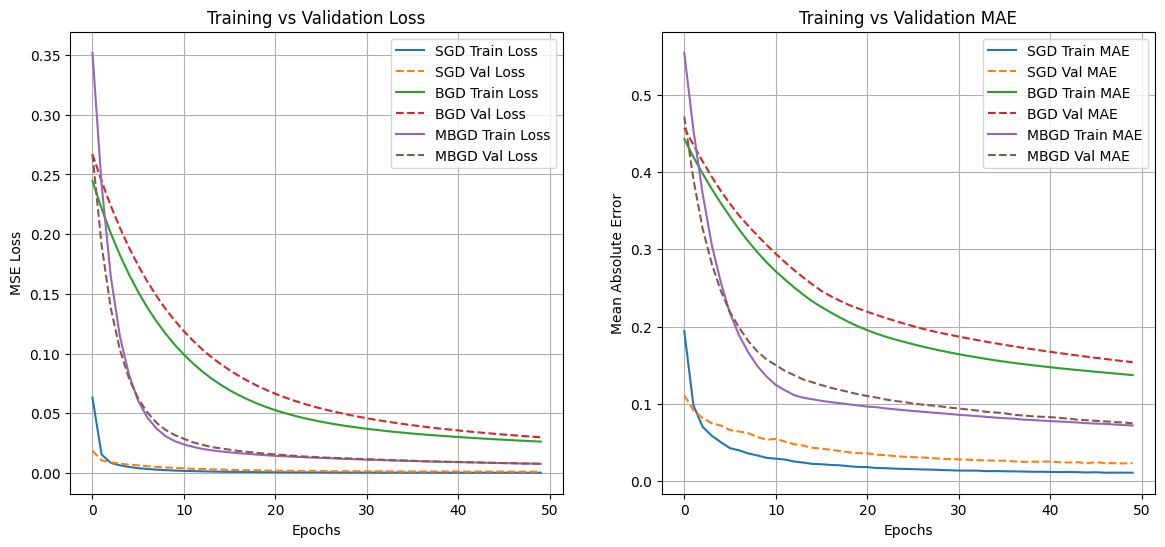

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/content/sample_data/house_prices.csv")

X = data.drop("Price", axis=1).values
y = data["Price"].values.reshape(-1,1)

# Scale features
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

# Scale target
scaler_y = MinMaxScaler()
y = scaler_y.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build ANN model function
def build_model():
    model = models.Sequential([
        layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])
    return model

# Train with different gradient descent variants
histories = {}

# 1. SGD (batch_size=1)
model_sgd = build_model()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss="mse", metrics=["mae"])
histories['SGD'] = model_sgd.fit(X_train, y_train, epochs=50, batch_size=1,
                                 validation_data=(X_test, y_test), verbose=0)

# 2. BGD (batch_size = dataset size)
model_bgd = build_model()
model_bgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss="mse", metrics=["mae"])
histories['BGD'] = model_bgd.fit(X_train, y_train, epochs=50, batch_size=len(X_train),
                                 validation_data=(X_test, y_test), verbose=0)

# 3. MBGD (batch_size=32)
model_mbgd = build_model()
model_mbgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                   loss="mse", metrics=["mae"])
histories['MBGD'] = model_mbgd.fit(X_train, y_train, epochs=50, batch_size=32,
                                   validation_data=(X_test, y_test), verbose=0)

# Plot comparison
plt.figure(figsize=(14,6))

# Loss curves
plt.subplot(1,2,1)
for key in histories:
    plt.plot(histories[key].history['loss'], label=f'{key} Train Loss')
    plt.plot(histories[key].history['val_loss'], linestyle='--', label=f'{key} Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

# MAE curves
plt.subplot(1,2,2)
for key in histories:
    plt.plot(histories[key].history['mae'], label=f'{key} Train MAE')
    plt.plot(histories[key].history['val_mae'], linestyle='--', label=f'{key} Val MAE')
plt.title("Training vs Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.grid(True)

plt.show()
